<a href="https://colab.research.google.com/github/cathyliu0510/15.071-Final-Project/blob/main/15_071_Final_Project_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Logistic Regression

In [7]:
# Run this cell to import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Run this code cell
def significance_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    elif p < 0.1:
        return '.'
    else:
        return ''

def print_summary_with_stars(model):
    """
    Print a comprehensive summary for GLM logistic regression models with significance stars
    """
    print("=" * 80)
    print("Logistic Regression Results")
    print("=" * 80)

    # Print basic model info for GLM
    print(f"Model Family: {model.family.__class__.__name__}")
    print(f"Link Function: {model.family.link.__class__.__name__}")
    print(f"Method: Maximum Likelihood Estimation (MLE)")
    print(f"Date: {model.summary().extra_txt}")
    print(f"No. Observations: {int(model.nobs)}")
    print(f"Df Model: {int(model.df_model)}")
    print(f"Df Residuals: {int(model.df_resid)}")

    print("-" * 40)
    print("Model Fit Statistics:")
    print(f"Log-Likelihood: {model.llf:.4f}")
    print(f"AIC: {model.aic:.4f}")
    print(f"BIC: {model.bic:.4f}")

    # For GLM, use pseudo R-squared instead of regular R-squared
    if hasattr(model, 'prsquared'):
        print(f"Pseudo R-squared (McFadden): {model.prsquared:.4f}")

    # Likelihood Ratio Test if available
    if hasattr(model, 'llr') and hasattr(model, 'llr_pvalue'):
        print(f"LLR p-value: {model.llr_pvalue:.4f}")

    print("=" * 80)
    print("Coefficients:")
    print("-" * 80)

    # Create coefficients table manually
    coef_data = {
        'Coef': model.params,
        'Std Err': model.bse,
        'z': model.tvalues,
        'P>|z|': model.pvalues,
        '[0.025': model.conf_int()[0],
        '0.975]': model.conf_int()[1]
    }

    coef_table = pd.DataFrame(coef_data)

    # Add significance stars
    coef_table['Signif'] = coef_table['P>|z|'].apply(significance_stars)

    # Round numeric columns to 4 decimal places
    numeric_columns = ['Coef', 'Std Err', 'z', 'P>|z|', '[0.025', '0.975]']
    for col in numeric_columns:
        coef_table[col] = coef_table[col].round(4)

    # Print the table
    print(coef_table.to_string())

    print("=" * 80)
    print("Significance codes: '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1")
    print("=" * 80)

In [12]:
df = pd.read_csv("global_supply_chain_risk_2026.csv")
df = df.replace("Los Angeles", "Los_Angeles")
df.head(5)

,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
0,SC-10000,2025-10-16,Singapore,Los_Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1
1,SC-10001,2024-04-24,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1
2,SC-10002,2024-01-26,Rotterdam,Los_Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0
3,SC-10003,2024-10-08,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1
4,SC-10004,2024-09-07,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1


In [13]:
df["Date"] = pd.to_datetime(df["Date"])

# Extract features
df["month"] = df["Date"].dt.month
df["dayofweek"] = df["Date"].dt.dayofweek

# Drop unused columns
df = df.drop(columns=["Date", "Lead_Time_Days", "Shipment_ID"])

# Add month + dayofweek to categorical list
categorical_cols = [
    "Origin_Port",
    "Destination_Port",
    "Transport_Mode",
    "Product_Category",
    "Weather_Condition",
    "month",
    "dayofweek"
]

# One-hot encode everything
df = pd.get_dummies(
    df,
    columns=categorical_cols,
    dtype=int,
    drop_first=True
)

num_cols = [
    "Distance_km",
    "Weight_MT",
    "Fuel_Price_Index",
    "Geopolitical_Risk_Score",
    "Carrier_Reliability_Score",
]

scaler = StandardScaler()

df[num_cols] = scaler.fit_transform(df[num_cols])

print(df.shape[0],df.shape[1])
df

5000 49


,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Carrier_Reliability_Score,Disruption_Occurred,Origin_Port_Busan,Origin_Port_Dubai,Origin_Port_Hamburg,Origin_Port_Los_Angeles,...,month_9,month_10,month_11,month_12,dayofweek_1,dayofweek_2,dayofweek_3,dayofweek_4,dayofweek_5,dayofweek_6
0,-0.422272,-0.342661,-0.442501,-0.026724,0.766289,1,0,0,0,0,...,0,1,0,0,0,0,1,0,0,0
1,1.567248,-0.063239,-0.577997,0.842072,-1.124965,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,0.812010,1.271280,-1.119982,0.181787,-0.563824,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,0.351606,-0.530440,0.360053,-1.486302,0.537676,1,1,0,0,0,...,0,1,0,0,1,0,0,0,0,0
4,-1.176823,1.324189,-0.088127,-1.104032,-0.092742,1,1,0,0,0,...,1,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,1.383145,1.282156,0.516394,1.293846,-0.626173,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4996,-1.303333,1.421727,-1.109559,-1.590558,0.752434,0,0,1,0,0,...,0,0,1,0,0,0,0,0,0,1
4997,-0.583517,1.593998,-1.547316,-0.721761,1.438273,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0
4998,1.101203,-0.329118,0.620622,-0.235235,0.447616,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [14]:
X = df.drop("Disruption_Occurred", axis=1)
y = df["Disruption_Occurred"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=25
)

X_train_const = sm.add_constant(X_train)

model = sm.GLM(y_train, X_train_const, family=sm.families.Binomial())
result = model.fit()

print_summary_with_stars(result)

Logistic Regression Results
Model Family: Binomial
Link Function: Logit
Method: Maximum Likelihood Estimation (MLE)
Date: None
No. Observations: 3500
Df Model: 48
Df Residuals: 3451
----------------------------------------
Model Fit Statistics:
Log-Likelihood: -1608.9465
AIC: 3315.8929
BIC: -24944.0555
Coefficients:
--------------------------------------------------------------------------------
                                     Coef     Std Err        z   P>|z|      [0.025      0.975] Signif
const                             -0.7023      0.2932  -2.3949  0.0166     -1.2770     -0.1275      *
Distance_km                       -0.0075      0.0435  -0.1717  0.8636     -0.0927      0.0777       
Weight_MT                         -0.0224      0.0428  -0.5232  0.6009     -0.1063      0.0615       
Fuel_Price_Index                   0.0185      0.0428   0.4309  0.6665     -0.0655      0.1024       
Geopolitical_Risk_Score            0.7387      0.0458  16.1434  0.0000      0.6490      0.8

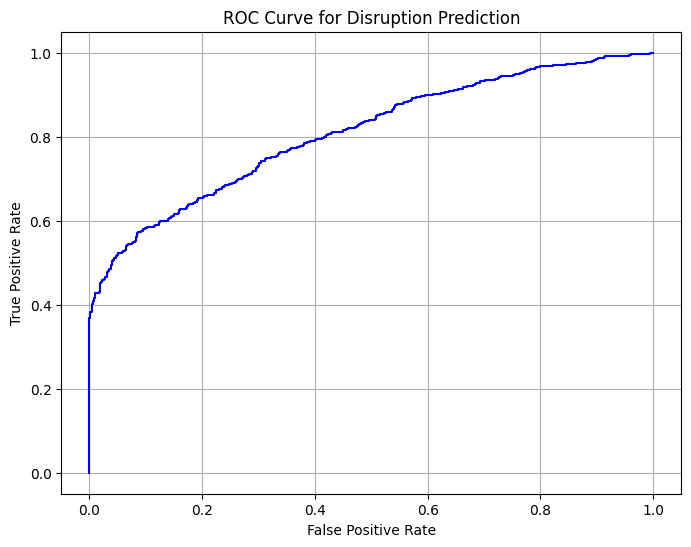

np.float64(0.8088446806546886)

In [15]:
X_test_const = sm.add_constant(X_test)
test_predictions = result.predict(X_test_const)
fpr_roc, tpr_roc, thresholds = roc_curve(y_test, test_predictions)

plt.figure(figsize = (8,6))
plt.plot(fpr_roc, tpr_roc, color = 'blue')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Disruption Prediction')
plt.grid(True)
plt.show()

roc_auc = auc(fpr_roc, tpr_roc)
roc_auc